## Punto 1 – Procesamiento de Imágenes en Python (50%)

### Enunciado

1. **Carga y visualización de una imagen (RGB) de un animal en via de extinción:**
   - Carga una imagen a color (RGB) desde archivo.
   - Muestra la imagen original en una figura.

2. **Filtros básicos:**
   Aplica los siguientes filtros a la imagen :
   - Suavizado / desenfoque
   - Realce de bordes

   Para cada filtro:
   - Muestra la imagen resultante.
   - Escribe en el notebook un breve comentario sobre el efecto visual observado.

3. **Visualización de canales de color:**
   - Separa la imagen original en sus tres canales (R, G, B).
   - Muestra en una figura:
     - Los tres canales en escala de grises (cada canal por separado).
   - Explica brevemente qué estructuras se ven más claras u oscuras en cada canal y por qué.

4. **Operaciones morfológicas :**
   - Trabaja sobre una versión en escala de grises o binarizada de la imagen.
   - Aplica dos operaciones morfológicas diferentes

   - Muestra los resultados comparando:
     - Imagen original (o binarizada).
     - Imagen después de cada operación.
   - Explica brevemente que efecto tuvo la operación sobre la imagen

5. **Animación:**
   - Genera una animación simple  o creando un GIF a partir de varios frames donde se vea:
     - La imagen original.
     - Los resultados de los filtros y/o operaciones morfológicas de forma secuencial.


In [1]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import imageio
import os

##**1. Carga y visualización**

En esta sección cargamos una imagen RGB de un animal en vía de extinción. Visualizar la imagen original nos permite tener un punto de referencia para evaluar los efectos de los filtros y transformaciones posteriores.

Sube una imagen RGB de un animal en vía de extinción


Saving panda 2.jpg to panda 2.jpg


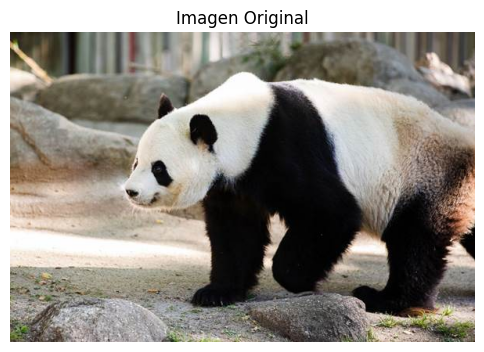

In [2]:
print("Sube una imagen RGB de un animal en vía de extinción")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.title("Imagen Original")
plt.imshow(img)
plt.axis("off")
plt.show()


##**2. Filtros básicos**


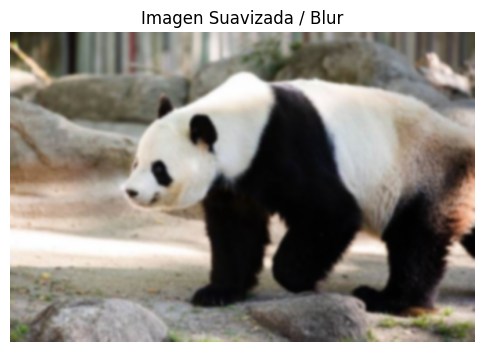

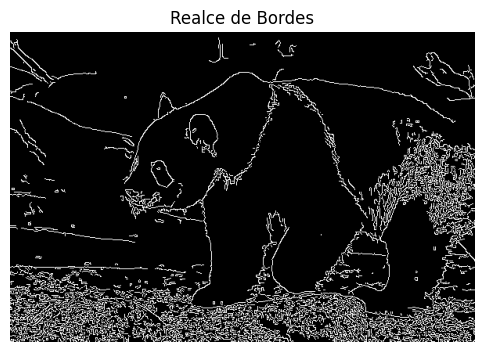

In [3]:

# Filtro suavizado
blur = cv2.GaussianBlur(img, (9,9), 0)

plt.figure(figsize=(6,6))
plt.title("Imagen Suavizada / Blur")
plt.imshow(blur)
plt.axis("off")
plt.show()

# Filtro de bordes Canny
edges = cv2.Canny(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), 100, 200)

plt.figure(figsize=(6,6))
plt.title("Realce de Bordes")
plt.imshow(edges, cmap='gray')
plt.axis("off")
plt.show()

##**3. Visualización de canales RGB**


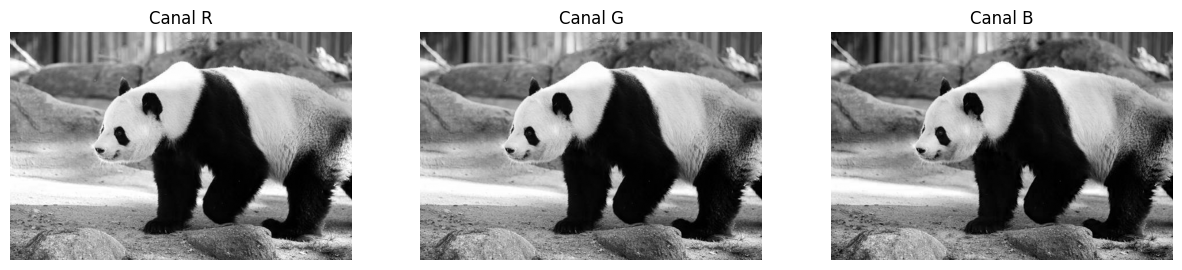

In [4]:
R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(R, cmap="gray"); ax[0].set_title("Canal R")
ax[1].imshow(G, cmap="gray"); ax[1].set_title("Canal G")
ax[2].imshow(B, cmap="gray"); ax[2].set_title("Canal B")
for a in ax: a.axis("off")
plt.show()

#**4. Operaciones morfológicas**


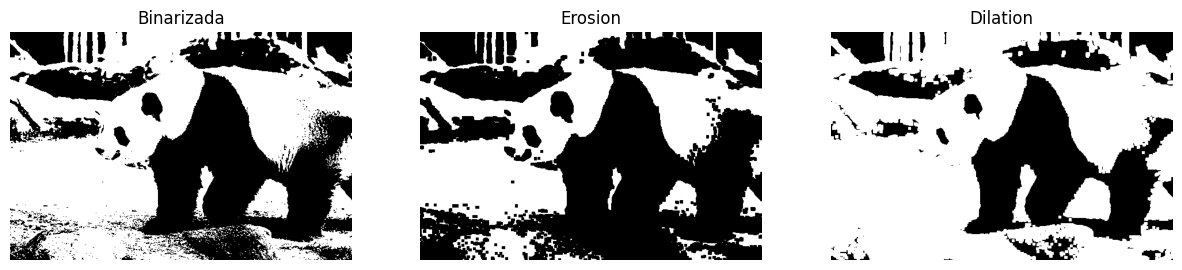

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)

erosion = cv2.erode(thresh, kernel, iterations=1)
dilation = cv2.dilate(thresh, kernel, iterations=1)

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(thresh, cmap="gray"); ax[0].set_title("Binarizada")
ax[1].imshow(erosion, cmap="gray"); ax[1].set_title("Erosion")
ax[2].imshow(dilation, cmap="gray"); ax[2].set_title("Dilation")
for a in ax: a.axis("off")
plt.show()


##**5. Animación (GIF)**


GIF 1 generado en: gifs/filtros.gif


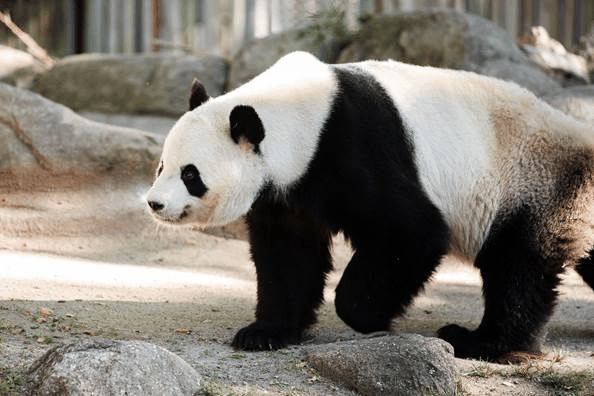

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from IPython.display import Image as ColabImage

os.makedirs("gifs", exist_ok=True)

# -------------------------
# GIF 1 - Filtros básicos
# -------------------------
frames_filters = [
    img,
    blur,
    cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB),
]

gif_filters_path = "gifs/filtros.gif"
imageio.mimsave(gif_filters_path, frames_filters, duration=0.8)

print("GIF 1 generado en:", gif_filters_path)

# Mostrar GIF en el notebook
display(ColabImage(gif_filters_path))

# Descargar
files.download(gif_filters_path)





GIF 2 generado en: gifs/morfologia.gif


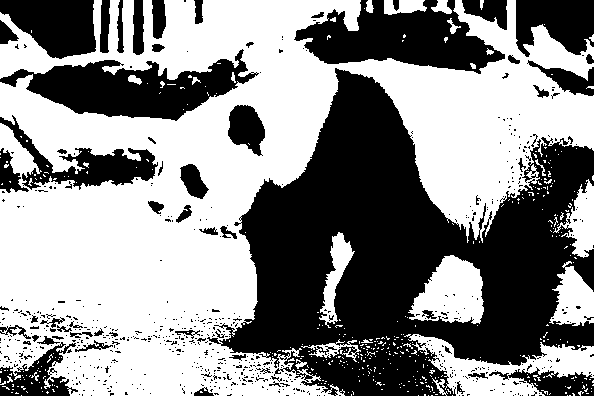

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
frames_morph = [
    cv2.cvtColor(thresh, cv2.COLOR_GRAY2RGB),
    cv2.cvtColor(erosion, cv2.COLOR_GRAY2RGB),
    cv2.cvtColor(dilation, cv2.COLOR_GRAY2RGB),
]

gif_morph_path = "gifs/morfologia.gif"
imageio.mimsave(gif_morph_path, frames_morph, duration=0.8)

print("GIF 2 generado en:", gif_morph_path)

# Mostrar en notebook
display(ColabImage(gif_morph_path))

# Descargar
files.download(gif_morph_path)